In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from datasets import load_dataset
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from collections import Counter
import random
import re
import string
import unicodedata
from tqdm import tqdm

# --- 1. Configuração Inicial ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
plt.style.use('seaborn-v0_8-whitegrid')
print(f"Usando dispositivo: {device}")

# --- 2. Definição dos Tokens Especiais e da Classe de Vocabulário ---

PAD_TOKEN = 0
SOS_TOKEN = 1 # Start-Of-Sentence
EOS_TOKEN = 2 # End-Of-Sentence
UNK_TOKEN = 3 # Unknown word

class Lang:
    """Classe para gerir o vocabulário (mapeamento palavra <-> índice)"""
    def __init__(self, name):
        self.name = name
        self.word2index = {"<pad>": PAD_TOKEN, "<sos>": SOS_TOKEN, "<eos>": EOS_TOKEN, "<unk>": UNK_TOKEN}
        self.word2count = {}
        self.index2word = {PAD_TOKEN: "<pad>", SOS_TOKEN: "<sos>", EOS_TOKEN: "<eos>", UNK_TOKEN: "<unk>"}
        self.n_words = 4 # Contagem de tokens especiais

    def add_sentence(self, sentence):
        for word in sentence.split(' '):
            self.add_word(word)

    def add_word(self, word):
        if word not in self.word2index:
            self.word2index[word] = self.n_words
            self.word2count[word] = 1
            self.index2word[self.n_words] = word
            self.n_words += 1
        else:
            self.word2count[word] += 1

# --- 3. Carregamento e Pré-processamento dos Dados ---

def normalize_string(s):
    """
    Normalização de texto para problemas matemáticos.
    Lowercase, preserva números e símbolos matemáticos essenciais.
    """
    s = s.lower().strip()

    # Adiciona espaços à volta de todos os símbolos e pontuação
    # para que sejam tokenizados como palavras separadas.
    s = re.sub(r"([.!?,\+\-\*/=(){}\[\]\^\\\$%])", r" \1 ", s)

    # Remove caracteres estranhos, mantendo letras, números e os símbolos
    s = re.sub(r"[^a-zA-Z0-9.!?,\+\-\*/=(){}\[\]\^\\\$%]+", r" ", s)

    # Contrai múltiplos espaços
    s = re.sub(r'\s+', ' ', s).strip()
    return s

# Carregar o dataset de matemática
try:
    raw_dataset = load_dataset("open-r1/OpenR1-Math-220k", split="train")
except Exception as e:
    print(f"Erro ao carregar o dataset: {e}")
    print("Por favor, verifique a sua conexão à Internet e se tem a biblioteca 'datasets' instalada.")
    # Usar dados mock para o notebook não falhar
    raw_dataset = [
        {'problem': 'What is 2 + 2?', 'solution': '2 + 2 = 4. The answer is \boxed{4}.'},
        {'problem': 'Calculate 10 - 3.', 'solution': '10 - 3 = 7. The answer is \boxed{7}.'}
    ]

# Limitar o número de pares e o comprimento para um treino rápido
MAX_PAIRS = 20000
MAX_LENGTH = 60 # Aumentar o limite para problemas matemáticos

pairs = []
for item in raw_dataset:
    # Usar 'problem' como input e 'solution' como output
    q = normalize_string(item['problem'])
    a = normalize_string(item['solution'])

    if len(q.split(' ')) < MAX_LENGTH and len(a.split(' ')) < MAX_LENGTH:
        pairs.append((q, a))

    if len(pairs) >= MAX_PAIRS:
        break

print(f"Total de pares de Q&A filtrados: {len(pairs)}")
print(random.choice(pairs))

# Construir os vocabulários
input_lang = Lang('question')
output_lang = Lang('solution')
for q, a in pairs:
    input_lang.add_sentence(q)
    output_lang.add_sentence(a)

print(f"Tamanho Vocabulário (Input - Pergunta): {input_lang.n_words}")
print(f"Tamanho Vocabulário (Output - Solução): {output_lang.n_words}")
print(f"Exemplo de token de solução: 'boxed' no vocabulário? {'boxed' in output_lang.word2index}")

# --- 4. Dataset e DataLoader do PyTorch ---
# (Idênticos ao notebook anterior)

def tensors_from_pair(pair, input_lang, output_lang):
    """Converte um par (pergunta, resposta) em tensores de índices"""
    input_tensor = [input_lang.word2index.get(word, UNK_TOKEN) for word in pair[0].split(' ')]
    input_tensor.append(EOS_TOKEN)

    target_tensor = [output_lang.word2index.get(word, UNK_TOKEN) for word in pair[1].split(' ')]
    target_tensor.append(EOS_TOKEN)

    return (torch.tensor(input_tensor, dtype=torch.long),
            torch.tensor(target_tensor, dtype=torch.long))

class QADataset(Dataset):
    def __init__(self, pairs, input_lang, output_lang):
        self.pairs = pairs
        self.input_lang = input_lang
        self.output_lang = output_lang

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        return tensors_from_pair(self.pairs[idx], self.input_lang, self.output_lang)

def collate_fn(batch):
    """Função de 'collate' para fazer padding dinâmico no batch"""
    batch.sort(key=lambda x: len(x[0]), reverse=True)
    inputs, targets = zip(*batch)

    padded_inputs = nn.utils.rnn.pad_sequence(inputs, batch_first=True, padding_value=PAD_TOKEN)
    padded_targets = nn.utils.rnn.pad_sequence(targets, batch_first=True, padding_value=PAD_TOKEN)

    return padded_inputs, padded_targets

BATCH_SIZE = 64
dataset = QADataset(pairs, input_lang, output_lang)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)

Usando dispositivo: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/20 [00:00<?, ?it/s]

data/train-00000-of-00010.parquet:   0%|          | 0.00/214M [00:00<?, ?B/s]

...

data/train-00007-of-00010.parquet:   0%|          | 0.00/216M [00:00<?, ?B/s]

data/train-00008-of-00010.parquet:   0%|          | 0.00/214M [00:00<?, ?B/s]

data/train-00009-of-00010.parquet:   0%|          | 0.00/215M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/93733 [00:00<?, ? examples/s]

Total de pares de Q&A filtrados: 2927
('1 . $ 12345 \\ times 11 = $ $ \\ qquad $ -', 'analysis original expression $ = 135795 $')
Tamanho Vocabulário (Input - Pergunta): 4927
Tamanho Vocabulário (Output - Solução): 3868
Exemplo de token de solução: 'boxed' no vocabulário? False


--- Iniciando Treinamento do Seq2Seq para Q&A de Matemática ---

Época 1/150, Custo: 5.4830

Época 2/150, Custo: 4.7569

Época 3/150, Custo: 4.4188

Época 4/150, Custo: 4.0521

Época 5/150, Custo: 3.7598

Época 6/150, Custo: 3.5664

Época 7/150, Custo: 3.4193

Época 8/150, Custo: 3.2890

Época 9/150, Custo: 3.1905

Época 10/150, Custo: 3.0959

Época 11/150, Custo: 3.0075

Época 12/150, Custo: 2.9289

Época 13/150, Custo: 2.8418

Época 14/150, Custo: 2.7902

Época 15/150, Custo: 2.7164

Época 16/150, Custo: 2.6491

Época 17/150, Custo: 2.5871

Época 18/150, Custo: 2.5169

Época 19/150, Custo: 2.4488

Época 20/150, Custo: 2.3941

Época 21/150, Custo: 2.3299

Época 22/150, Custo: 2.2627

Época 23/150, Custo: 2.2007

Época 24/150, Custo: 2.1395

Época 25/150, Custo: 2.0859

Época 26/150, Custo: 2.0122

Época 27/150, Custo: 1.9549

Época 28/150, Custo: 1.8964

Época 29/150, Custo: 1.8443

Época 30/150, Custo: 1.7985

Época 31/150, Custo: 1.7381

Época 32/150, Custo: 1.6782

Época 33/150, Cu

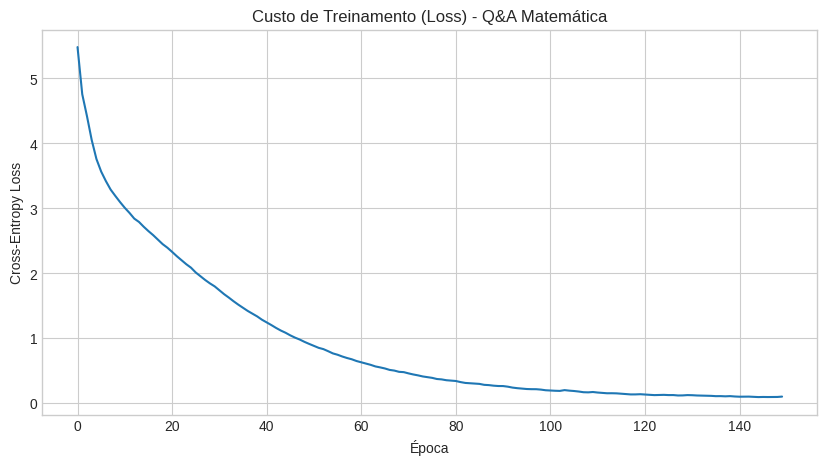


--- Testando o Modelo (Gerando Soluções) ---

> Pergunta: 67 . there are three steel pipes , with lengths of 240 cm , 200 cm , and 480 cm , respectively . if they are cut into segments of the same length , the longest each segment can be is $ \ qquad $ cm .
= Solução Real: answer 40


/tmp/ipython-input-1390434608.py:229: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + input_tokens, rotation=90)
/tmp/ipython-input-1390434608.py:230: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + decoded_words)


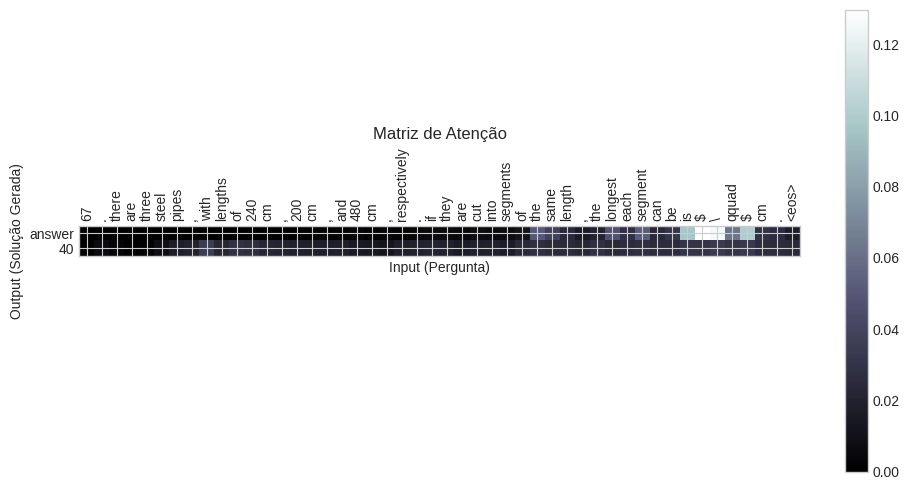

< Solução Gerada: answer 40

> Pergunta: how many different seven - digit telephone numbers exist ( assuming that a number cannot start with zero ) ?
= Solução Real: the first digit can be chosen in 9 ways , and each of the six remaining digits can be chosen in 10 ways . in total , $ 9 \ cdot 10 ^ { 6 } $ ways . answer $ 9 \ cdot 10 ^ { 6 } $ numbers .


/tmp/ipython-input-1390434608.py:229: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + input_tokens, rotation=90)
/tmp/ipython-input-1390434608.py:230: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + decoded_words)


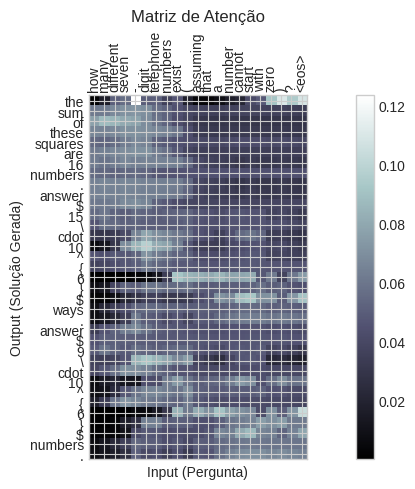

< Solução Gerada: the sum of these squares are 16 numbers . answer $ 15 \ cdot 10 ^ { 6 } $ ways . answer $ 9 \ cdot 10 ^ { 6 } $ numbers .

> Pergunta: 13 . in the number 513879406 , cross out 4 digits so that the remaining digits in the same order form a ) the largest number b ) the smallest number .
= Solução Real: 13 . a ) $ 89406 $ ) 13406 .


/tmp/ipython-input-1390434608.py:229: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + input_tokens, rotation=90)
/tmp/ipython-input-1390434608.py:230: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + decoded_words)


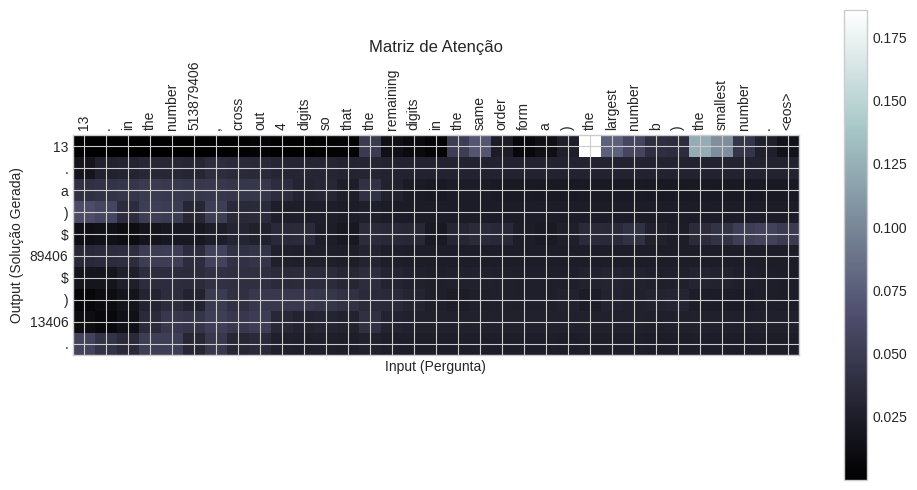

< Solução Gerada: 13 . a ) $ 89406 $ ) 13406 .

> Pergunta: 10 . a string of beads is arranged according to a pattern , the box covers a total of 12 beads , among these 12 beads , there are ( ) white beads . a . 3 b . 4 c . 5 d . 6 e . 7
= Solução Real: d translate the text above into english , please retain the original text s line breaks and format , and output the translation result directly .


/tmp/ipython-input-1390434608.py:229: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + input_tokens, rotation=90)
/tmp/ipython-input-1390434608.py:230: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + decoded_words)


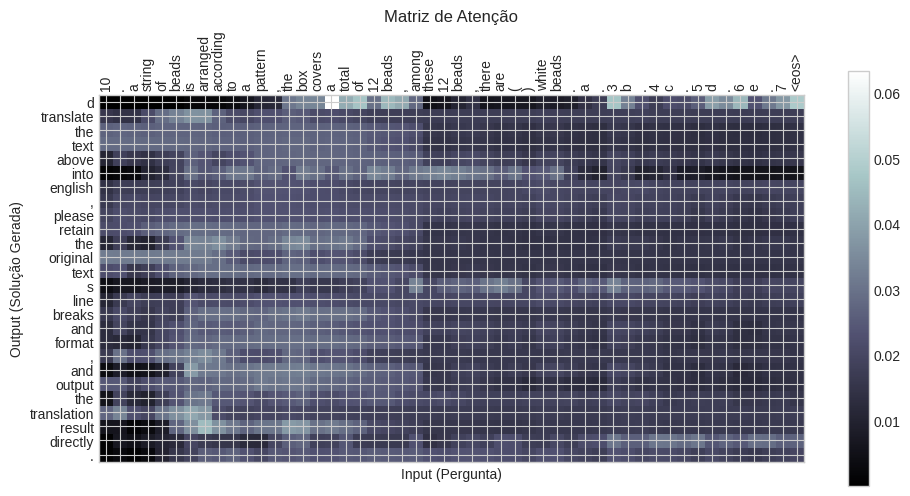

< Solução Gerada: d translate the text above into english , please retain the original text s line breaks and format , and output the translation result directly .

> Pergunta: 5 . find a sequence $ \ { f ( n ) \ } { n \ geqslant 0 } $ , whose first 4 terms are $ 3 , 7 , 21 , 51 $ , and whose general term $ f ( n ) $ is a polynomial in $ n $ of the lowest degree .
= Solução Real: 5 . $ f ( n ) = n ^ { 3 } + 2 n ^ { 2 } + n + 3 $ . the above text has been translated into english , retaining the original text s line breaks and format .


/tmp/ipython-input-1390434608.py:229: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + input_tokens, rotation=90)
/tmp/ipython-input-1390434608.py:230: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + decoded_words)


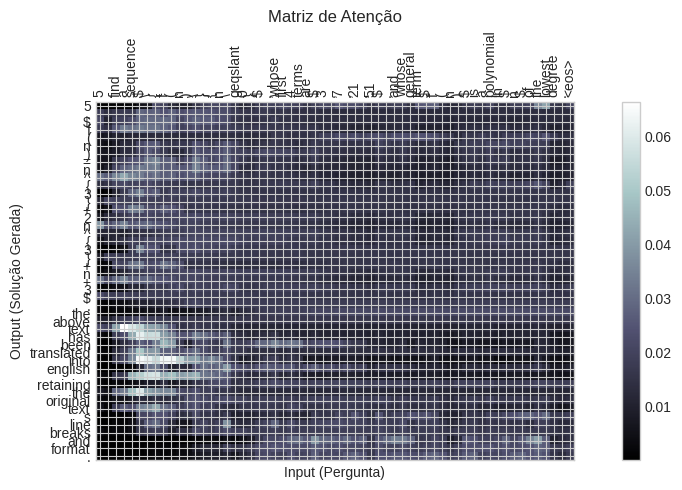

< Solução Gerada: 5 . $ f ( n ) = n ^ { 3 } + 2 n ^ { 3 } + n + 3 $ . the above text has been translated into english , retaining the original text s line breaks and format .

--- Teste Manual ---
> Pergunta: What is 10 + 5?


/tmp/ipython-input-1390434608.py:229: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + input_tokens, rotation=90)
/tmp/ipython-input-1390434608.py:230: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + decoded_words)


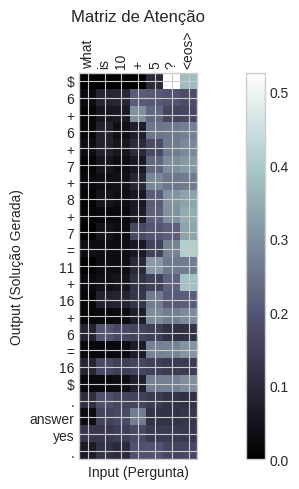

< Solução Gerada: $ 6 + 6 + 7 + 8 + 7 = 11 + 16 + 6 = 16 $ . answer yes .


In [ ]:


# --- 5. Definição da Arquitetura Seq2Seq com Atenção ---
# (Exatamente as mesmas classes do notebook anterior)

class EncoderRNN(nn.Module):
    def __init__(self, input_size, hidden_size, embed_size):
        super(EncoderRNN, self).__init__()
        self.hidden_size = hidden_size
        self.embedding = nn.Embedding(input_size, embed_size, padding_idx=PAD_TOKEN)
        self.gru = nn.GRU(embed_size, hidden_size, batch_first=True, num_layers=2, dropout=0.2) # Aumentado para 2 camadas

    def forward(self, input_seq):
        embedded = self.embedding(input_seq)
        outputs, hidden = self.gru(embedded)
        # outputs: [batch_size, seq_len, hidden_size]
        # hidden: [num_layers, batch_size, hidden_size]
        return outputs, hidden

class Attention(nn.Module):
    def __init__(self, hidden_size):
        super(Attention, self).__init__()
        self.hidden_size = hidden_size
        # Camada para alinhar a Query e as Keys
        self.attn = nn.Linear(hidden_size * 2, hidden_size)
        # Vetor 'v' para reduzir a energia a um score
        self.v = nn.Parameter(torch.rand(hidden_size))

    def forward(self, decoder_hidden, encoder_outputs):
        # decoder_hidden (Query): [num_layers, B, H]
        # encoder_outputs (Keys/Values): [B, S, H]

        # 1. Obter a Query (Q)
        # Pegar apenas a última camada do hidden do decoder
        query = decoder_hidden[-1] # [B, H]

        # 2. Obter as Keys (K) e os Values (V)
        # No nosso caso, os outputs do encoder são ambos
        keys = encoder_outputs   # [B, S, H]
        values = encoder_outputs # [B, S, H]

        batch_size = keys.shape[0]
        seq_len = keys.shape[1]

        # 3. Calcular Scores (Usando "Additive Attention")

        # Expandir a Query [B, H] -> [B, S, H] para concatenar com as Keys
        query_expanded = query.unsqueeze(1).repeat(1, seq_len, 1)

        # Concatenar Query e Keys [B, S, H*2]
        attn_input = torch.cat((query_expanded, keys), dim=2)

        # Calcular "Energy" (pontuação intermediária) [B, S, H]
        energy = torch.tanh(self.attn(attn_input))

        # Reduzir para scores finais [B, S]
        # [B, 1, H] @ [B, H, S] -> [B, 1, S]
        v_expanded = self.v.repeat(batch_size, 1).unsqueeze(1)
        scores = torch.bmm(v_expanded, energy.permute(0, 2, 1)).squeeze(1) # [B, S]

        # 4. Calcular Pesos (Weights)
        # Normalizar os scores para obter uma distribuição de probabilidade
        weights = F.softmax(scores, dim=1).unsqueeze(1) # [B, 1, S]

        # 5. Calcular Vetor de Contexto (Context Vector)
        # Multiplicar os pesos pelos Values
        # [B, 1, S] @ [B, S, H] -> [B, 1, H]
        context_vector = torch.bmm(weights, values)

        # Retorna o contexto e os pesos (para visualização)
        return context_vector, weights.squeeze(1)


class AttnDecoderRNN(nn.Module):
    def __init__(self, output_size, hidden_size, embed_size, num_layers=2):
        super(AttnDecoderRNN, self).__init__()
        self.hidden_size = hidden_size
        self.embedding = nn.Embedding(output_size, embed_size, padding_idx=PAD_TOKEN)
        self.attention = Attention(hidden_size)
        self.gru = nn.GRU(embed_size + hidden_size, hidden_size, batch_first=True, num_layers=num_layers, dropout=0.2)
        self.out = nn.Linear(hidden_size, output_size)

    def forward(self, decoder_input, decoder_hidden, encoder_outputs):
        # decoder_input: [batch_size, 1]
        # decoder_hidden: [num_layers, batch_size, hidden_size]
        # encoder_outputs: [batch_size, seq_len, hidden_size]

        embedded = self.embedding(decoder_input) # [batch_size, 1, embed_size]

        context, attn_weights = self.attention(decoder_hidden, encoder_outputs)
        # context: [batch_size, 1, hidden_size]

        rnn_input = torch.cat((embedded, context), dim=2) # [batch_size, 1, embed_size + hidden_size]

        output, hidden = self.gru(rnn_input, decoder_hidden)
        # output: [batch_size, 1, hidden_size]
        # hidden: [num_layers, batch_size, hidden_size]

        logits = self.out(output.squeeze(1)) # [batch_size, output_size]

        return logits, hidden, attn_weights

# --- 6. Função de Treinamento ---
# (Idêntica ao notebook anterior)

def train_epoch(dataloader, encoder, decoder, encoder_optimizer, decoder_optimizer, criterion):
    total_loss = 0
    encoder.train()
    decoder.train()

    for inputs, targets in dataloader:
        inputs, targets = inputs.to(device), targets.to(device)

        encoder_optimizer.zero_grad()
        decoder_optimizer.zero_grad()

        encoder_outputs, encoder_hidden = encoder(inputs)

        decoder_hidden = encoder_hidden
        decoder_input = torch.full((inputs.shape[0], 1), SOS_TOKEN, dtype=torch.long, device=device)

        batch_loss = 0
        max_target_len = targets.shape[1]

        for t in range(max_target_len):
            logits, decoder_hidden, _ = decoder(decoder_input, decoder_hidden, encoder_outputs)

            loss = criterion(logits, targets[:, t])
            batch_loss += loss

            decoder_input = targets[:, t].unsqueeze(1) # Teacher Forcing

            if (decoder_input == PAD_TOKEN).all():
                break

        batch_loss = batch_loss / max_target_len
        batch_loss.backward()

        # Clip nos gradientes para evitar explosão
        torch.nn.utils.clip_grad_norm_(encoder.parameters(), 1)
        torch.nn.utils.clip_grad_norm_(decoder.parameters(), 1)

        encoder_optimizer.step()
        decoder_optimizer.step()

        total_loss += batch_loss.item()

    return total_loss / len(dataloader)

# --- 7. Execução do Treinamento ---

# Vocabulários maiores e tarefas mais complexas exigem modelos maiores
HIDDEN_SIZE = 256
EMBED_SIZE = 256
NUM_LAYERS = 2
NUM_EPOCHS = 150 # Aumentar épocas para uma tarefa mais difícil
LR = 0.001

encoder = EncoderRNN(input_lang.n_words, HIDDEN_SIZE, EMBED_SIZE).to(device)
decoder = AttnDecoderRNN(output_lang.n_words, HIDDEN_SIZE, EMBED_SIZE, NUM_LAYERS).to(device)

encoder_optimizer = optim.Adam(encoder.parameters(), lr=LR)
decoder_optimizer = optim.Adam(decoder.parameters(), lr=LR)
criterion = nn.CrossEntropyLoss(ignore_index=PAD_TOKEN)

print("--- Iniciando Treinamento do Seq2Seq para Q&A de Matemática ---")
loss_history = []
for epoch in range(1, NUM_EPOCHS + 1):
    loss = train_epoch(dataloader, encoder, decoder, encoder_optimizer, decoder_optimizer, criterion)
    loss_history.append(loss)
    print(f'\nÉpoca {epoch}/{NUM_EPOCHS}, Custo: {loss:.4f}')

# Plotar o custo
plt.figure(figsize=(10, 5))
plt.plot(loss_history)
plt.title('Custo de Treinamento (Loss) - Q&A Matemática')
plt.xlabel('Época')
plt.ylabel('Cross-Entropy Loss')
plt.grid(True)
plt.show()

# --- 8. Função de Geração (Inferência) e Visualização da Atenção ---
# (Idêntica ao notebook anterior, mas com o nome da função atualizado)

def answer_question_and_show_attention(input_sentence, encoder, decoder, max_len=MAX_LENGTH):
    encoder.eval()
    decoder.eval()

    with torch.no_grad():
        # Normalizar e converter a pergunta em tensor
        normalized_input = normalize_string(input_sentence)
        input_tensor = [input_lang.word2index.get(word, UNK_TOKEN) for word in normalized_input.split(' ')]
        input_tensor.append(EOS_TOKEN)
        input_tensor = torch.tensor(input_tensor, dtype=torch.long, device=device).unsqueeze(0) # [1, seq_len]

        encoder_outputs, encoder_hidden = encoder(input_tensor)

        decoder_hidden = encoder_hidden
        decoder_input = torch.tensor([[SOS_TOKEN]], device=device) # [1, 1]

        decoded_words = []
        decoder_attentions = torch.zeros(max_len, input_tensor.shape[1])

        for t in range(max_len):
            logits, decoder_hidden, attn_weights = decoder(decoder_input, decoder_hidden, encoder_outputs)

            decoder_attentions[t] = attn_weights.squeeze().cpu()
            topv, topi = logits.topk(1)
            next_word_idx = topi.item()

            if next_word_idx == EOS_TOKEN:
                decoded_words.append('<eos>')
                break
            else:
                decoded_words.append(output_lang.index2word[next_word_idx])

            decoder_input = torch.tensor([[next_word_idx]], device=device)

        input_tokens = normalized_input.split(' ') + ['<eos>']
        if decoded_words and decoded_words[-1] == '<eos>':
            decoded_words = decoded_words[:-1]

        output_sentence = ' '.join(decoded_words)

        # Plotar atenção
        fig = plt.figure(figsize=(10, 5))
        ax = fig.add_subplot(111)
        cax = ax.matshow(decoder_attentions[:len(decoded_words), :len(input_tokens)].numpy(), cmap='bone')
        fig.colorbar(cax)

        ax.set_xticklabels([''] + input_tokens, rotation=90)
        ax.set_yticklabels([''] + decoded_words)
        ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
        ax.yaxis.set_major_locator(ticker.MultipleLocator(1))

        plt.title("Matriz de Atenção")
        plt.xlabel("Input (Pergunta)")
        plt.ylabel("Output (Solução Gerada)")
        plt.tight_layout()
        plt.show()

        return output_sentence

# --- 9. Testar o Modelo ---

print("\n--- Testando o Modelo (Gerando Soluções) ---")
for i in range(5):
    pair = random.choice(pairs)
    print(f"\n> Pergunta: {pair[0]}")
    print(f"= Solução Real: {pair[1]}")
    output_sentence = answer_question_and_show_attention(pair[0], encoder, decoder)
    print(f"< Solução Gerada: {output_sentence}")

# Testar com uma pergunta manual
print("\n--- Teste Manual ---")
manual_question = "What is 10 + 5?"
print(f"> Pergunta: {manual_question}")
output_sentence = answer_question_and_show_attention(manual_question, encoder, decoder)
print(f"< Solução Gerada: {output_sentence}")